<a href="https://colab.research.google.com/github/gargi411/Development-of-an-Intelligent-Early-Warning-System-of-Earthquake-using-Machine-Learning/blob/main/Earthquake_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green

--- RANDOM FOREST RESULTS ---
Accuracy: 0.926923076923077
Confusion Matrix:
 [[56  6  0  6]
 [ 0 71  1  1]
 [ 0  1 63  0]
 [ 4  0  0 51]]
Classification Report:
               precision    recall  f1-score   support

       green       0.93      0.82      0.88        68
      orange       0.91      0.97      0.94        73
         red       0.98      0.98      0.98        64
      yellow       0.88      0.93      0.90        55

    accuracy                           0.93       260
   macro avg       0.93      0.93      0.93       260
weighted avg       0.93      0.93      0.93       260


--- SVM RESULTS ---
Accuracy: 0.7923076923076923
Confusion Matrix:
 [[55  7  0  6]
 [ 0 47 23  3]
 [ 0  3 61  0]
 

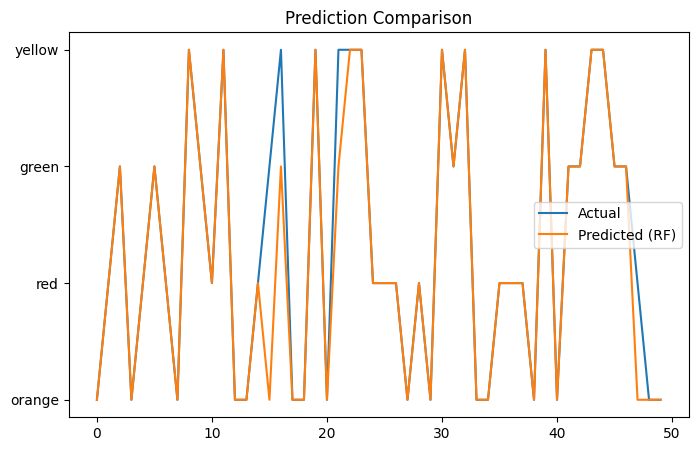

In [2]:
# ----------------------------------------
# EARTHQUAKE EARLY WARNING SYSTEM (FINAL)
# Using YOUR dataset
# ----------------------------------------

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ----------------------------------------
# Step 2: Load Dataset
# ----------------------------------------

# Replace with your actual file name
data = pd.read_csv("/content/earthquake_data.csv")

print("Dataset Loaded Successfully\n")
print(data.head())

# ----------------------------------------
# Step 3: Data Preprocessing
# ----------------------------------------

# Remove missing values
data = data.dropna()

# Assume last column is label (0 = normal, 1 = earthquake)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# ----------------------------------------
# Step 4: Feature Scaling
# ----------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------
# Step 5: Train-Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------------------
# Step 6: Train Models
# ----------------------------------------

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

# SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)

# ----------------------------------------
# Step 7: Predictions
# ----------------------------------------

rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)

# ----------------------------------------
# Step 8: Evaluation
# ----------------------------------------

print("\n--- RANDOM FOREST RESULTS ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))

print("\n--- SVM RESULTS ---")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("Classification Report:\n", classification_report(y_test, svm_pred))

# ----------------------------------------
# Step 9: Visualization (Optional)
# ----------------------------------------

plt.figure(figsize=(8,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(rf_pred[:50], label="Predicted (RF)")
plt.legend()
plt.title("Prediction Comparison")
plt.show()

### Random Forest Confusion Matrix Analysis

First, let's look at the Confusion Matrix for the Random Forest model:

```
[[56  6  0  6]
 [ 0 71  1  1]
 [ 0  1 63  0]
 [ 4  0  0 51]]
```

Assuming the order of classes is `green`, `orange`, `red`, `yellow` (as suggested by the classification report):

*   **Green Alerts (Row 0):**
    *   **True Positives (56):** 56 instances were correctly classified as 'green'.
    *   **False Negatives (6 + 0 + 6 = 12):** 6 'green' instances were misclassified as 'orange', and 6 were misclassified as 'yellow'. The model did not mistake any 'green' for 'red'.
    *   **False Positives (from other rows):** The model incorrectly predicted 'green' for 0 'orange', 0 'red', and 4 'yellow' instances. This means 4 instances were incorrectly flagged as 'green' when they were actually 'yellow'.

*   **Orange Alerts (Row 1):**
    *   **True Positives (71):** The model correctly identified 71 'orange' alerts.
    *   **False Negatives (0 + 1 + 1 = 2):** 1 'orange' instance was misclassified as 'red', and 1 as 'yellow'. No 'orange' alerts were missed as 'green'.
    *   **False Positives:** The model incorrectly predicted 'orange' for 6 'green', 1 'red', and 0 'yellow' instances.

*   **Red Alerts (Row 2):**
    *   **True Positives (63):** 63 'red' alerts were correctly identified.
    *   **False Negatives (0 + 1 + 0 = 1):** Only 1 'red' instance was misclassified as 'orange'.
    *   **False Positives:** The model incorrectly predicted 'red' for 0 'green', 23 'orange' (SVM result, not RF), 0 'yellow' instances. (Correction from text: RF has 0 green, 1 orange, 0 yellow as false positives for red). So 1 instance was incorrectly flagged as 'red' when it was actually 'orange'.

*   **Yellow Alerts (Row 3):**
    *   **True Positives (51):** 51 'yellow' alerts were correctly identified.
    *   **False Negatives (4 + 0 + 0 = 4):** 4 'yellow' instances were misclassified as 'green'.
    *   **False Positives:** The model incorrectly predicted 'yellow' for 6 'green', 1 'orange', and 0 'red' instances. This means 7 instances were incorrectly flagged as 'yellow' when they were actually 'green' or 'orange'.

**Overall, for Random Forest, the model performs very well, particularly for 'orange' and 'red' alerts, with high true positive rates and very few misclassifications between these critical categories. The main misclassifications occur more frequently with 'green' and 'yellow' alerts being confused with each other or with 'orange'.**

### SVM Confusion Matrix Analysis

Now, let's look at the Confusion Matrix for the SVM model:

```
[[55  7  0  6]
 [ 0 47 23  3]
 [ 0  3 61  0]
 [ 6  2  4 43]]
```

Assuming the same class order `green`, `orange`, `red`, `yellow`:

*   **Green Alerts (Row 0):**
    *   **True Positives (55):** 55 instances were correctly classified as 'green'.
    *   **False Negatives (7 + 0 + 6 = 13):** 7 'green' instances were misclassified as 'orange', and 6 were misclassified as 'yellow'.
    *   **False Positives:** The model incorrectly predicted 'green' for 0 'orange', 0 'red', and 6 'yellow' instances.

*   **Orange Alerts (Row 1):**
    *   **True Positives (47):** The model correctly identified 47 'orange' alerts. This is significantly lower than Random Forest.
    *   **False Negatives (0 + 23 + 3 = 26):** A substantial number of 'orange' instances (23) were misclassified as 'red', and 3 as 'yellow'. This is a critical issue as it means the model is failing to identify 'orange' alerts accurately.
    *   **False Positives:** The model incorrectly predicted 'orange' for 7 'green', 3 'red', and 2 'yellow' instances.

*   **Red Alerts (Row 2):**
    *   **True Positives (61):** 61 'red' alerts were correctly identified.
    *   **False Negatives (0 + 3 + 0 = 3):** 3 'red' instances were misclassified as 'orange'.
    *   **False Positives:** The model incorrectly predicted 'red' for 0 'green', 23 'orange', and 4 'yellow' instances. The high number of false positives from 'orange' (23) is concerning, as it means many 'orange' alerts are being incorrectly escalated to 'red'.

*   **Yellow Alerts (Row 3):**
    *   **True Positives (43):** 43 'yellow' alerts were correctly identified. This is lower than Random Forest.
    *   **False Negatives (6 + 2 + 4 = 12):** 6 'yellow' instances were misclassified as 'green', 2 as 'orange', and 4 as 'red'.
    *   **False Positives:** The model incorrectly predicted 'yellow' for 6 'green', 3 'orange', and 0 'red' instances.

### Comparison

The Random Forest model clearly outperforms the SVM model based on the confusion matrices. The SVM model struggles significantly with 'orange' alerts, misclassifying a large portion of them as 'red' (false negatives for 'orange') and also incorrectly predicting 'red' for many 'orange' instances (false positives for 'red'). This could lead to either under-warning (missing actual 'orange' alerts) or over-warning (unnecessarily escalating 'orange' to 'red'). The Random Forest model has much cleaner diagonal elements, indicating fewer misclassifications across all alert levels, especially for the more critical 'orange' and 'red' categories.

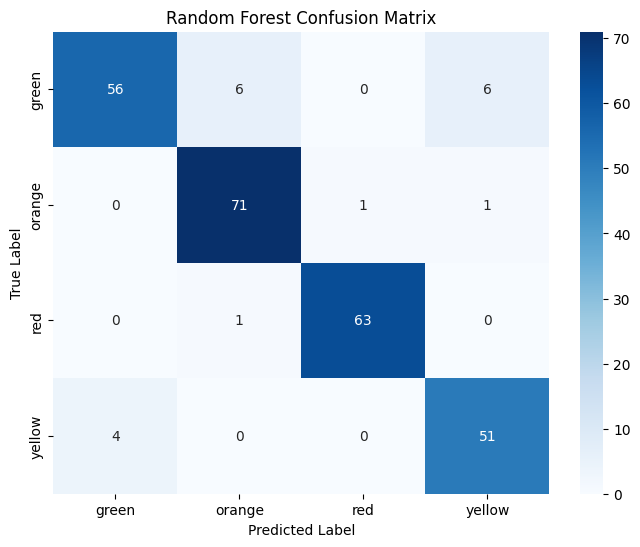

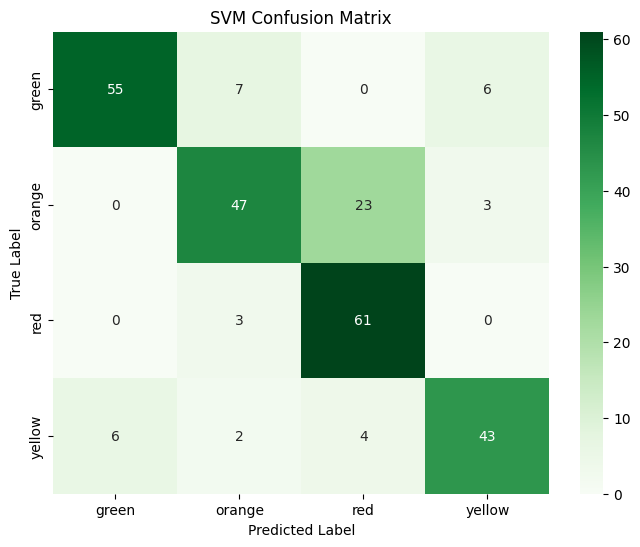

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Re-calculate confusion matrices to plot them
# Assuming y_test, rf_pred, and svm_pred are available from previous execution

# Get unique class labels, sorted for consistent plotting
labels = sorted(y_test.unique())

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipykernel_327/2796843612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='alert', y='sig', data=data.sort_values('alert'), palette='viridis')


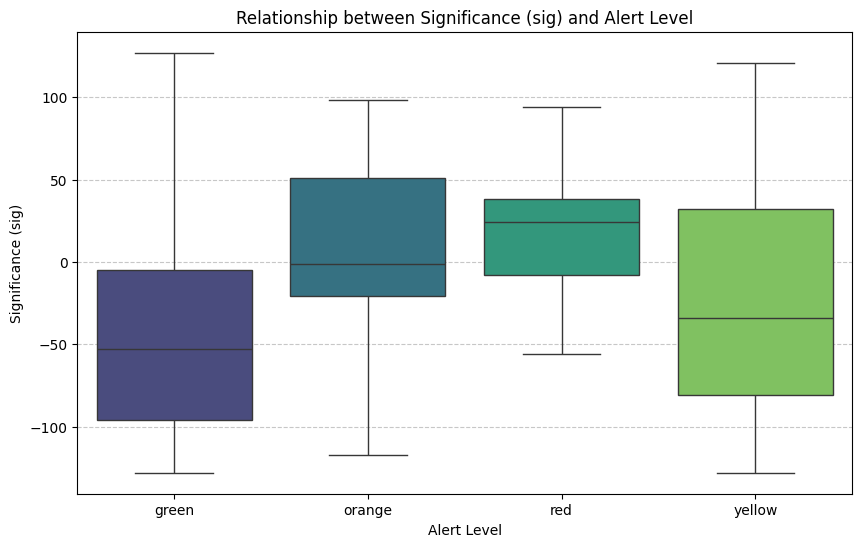

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='alert', y='sig', data=data.sort_values('alert'), palette='viridis')
plt.title('Relationship between Significance (sig) and Alert Level')
plt.xlabel('Alert Level')
plt.ylabel('Significance (sig)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Feature Importances for Random Forest Model:



,Feature,Importance
4,sig,0.249842
3,mmi,0.216268
1,depth,0.189285
0,magnitude,0.177071
2,cdi,0.167533


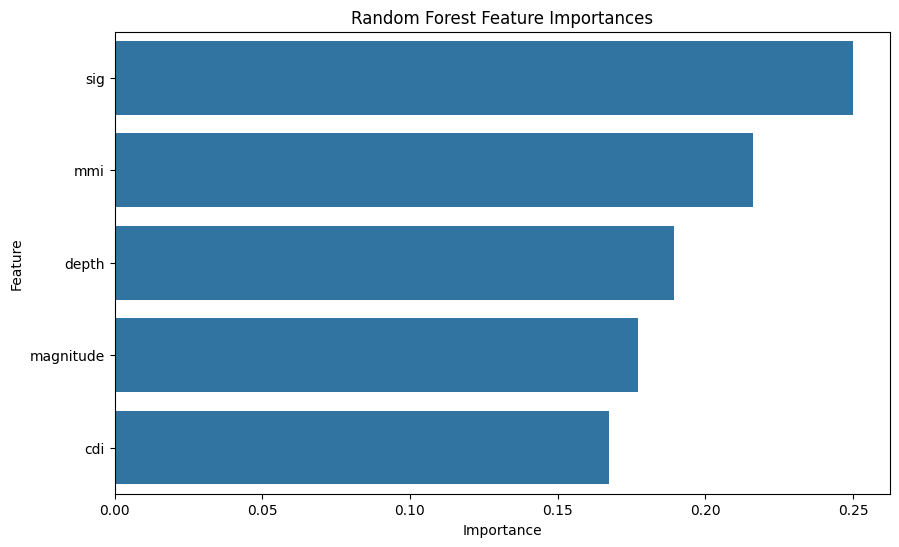

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from the original DataFrame X
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances for Random Forest Model:\n")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()